# Step 1: Import libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Step 2: Load California Housing Dataset

In [33]:
housing = fetch_california_housing(as_frame=True)

# Step 3: Create DataFrame

In [34]:
df = housing.frame

# Display first five records

In [35]:
print("First Five Rows:")
print(df.head())

First Five Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


# Display dataset information

In [36]:
print("\nDataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)


Dataset Shape: (20640, 9)

Columns:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


# Step 4: Select one feature (Simple Linear Regression)

In [37]:
X = df[['MedInc']]         
y = df['MedHouseVal']       


# Step 5: Split dataset

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 6: Create model

In [39]:
model = LinearRegression()

# Step 7: Train model

In [40]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Step 8: Predict values

In [41]:
y_pred = model.predict(X_test)


# Step 9: Print model parameters

In [42]:
print("\nModel Parameters")
print("--------------------")
print("Coefficient (Slope):", model.coef_[0])
print("Intercept:", model.intercept_)



Model Parameters
--------------------
Coefficient (Slope): 0.41933849393812705
Intercept: 0.4445972916907881


# Step 10: Evaluate Model

In [43]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nPerformance Metrics:")
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)



Performance Metrics:
Mean Squared Error (MSE): 0.7091157771765548
Root Mean Squared Error (RMSE): 0.8420901241414454
R2 Score: 0.45885918903846656


# Step 11: Plot Regression Line

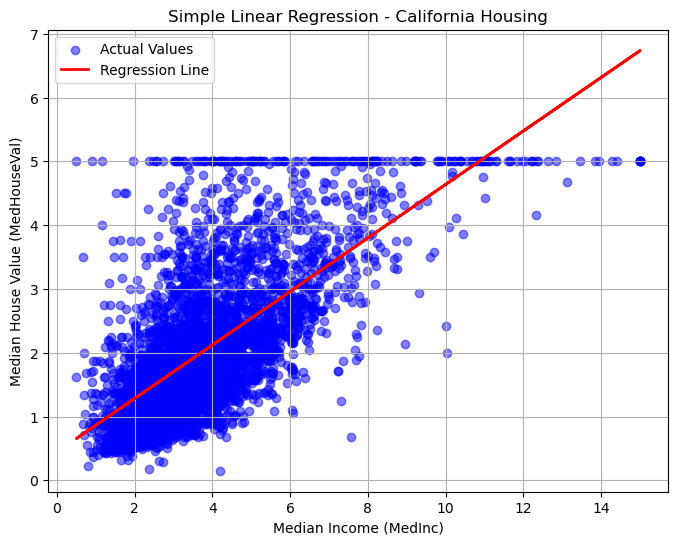

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test,
            color='blue',
            alpha=0.5,
            label='Actual Values')

plt.plot(X_test,
         y_pred,
         color='red',
         linewidth=2,
         label='Regression Line')

plt.title("Simple Linear Regression - California Housing")
plt.xlabel("Median Income (MedInc)")
plt.ylabel("Median House Value (MedHouseVal)")
plt.legend()
plt.grid(True)

plt.show()

In [57]:

new_income = pd.DataFrame({
    'MedInc': [10000, 20000, 30000]
})


new_house = model.predict(new_income)


for income, house in zip(new_income['MedInc'], new_house):
    print(f"If income is ${income}, predicted house price is ${house}")

If income is $10000, predicted house price is $4193.829536672962
If income is $20000, predicted house price is $8387.214476054232
If income is $30000, predicted house price is $12580.599415435503
